# Inciso 8. Interpretación y explicabilidad del modelo

Este notebook revisa los modelos de los incisos 4-7, selecciona el de mejor desempeño bajo validación espacial y explica sus predicciones mediante importancia global y SHAP. Se prioriza **recall** porque un falso negativo puede dejar sin detectar una zona con alta presencia de cianobacteria; F1 y ROC-AUC se usan como desempates.

## 8.0. Reproducibilidad y revisión de los incisos anteriores

Los notebooks anteriores ajustaron Regresión Logística, Random Forest y XGBoost. En la evaluación guardada, XGBoost alcanzó el mayor F1 aleatorio, mientras Random Forest logró el mayor ROC-AUC espacial. Debido a la autocorrelación geográfica, aquí se repite la comparación con los **7,194 registros completos**, manteniendo juntos los registros del mismo bloque de 1 km mediante `GroupShuffleSplit`.

Si faltan dependencias, se pueden instalar en el kernel con `%pip install shap xgboost`.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from IPython.display import Markdown, display
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, roc_auc_score)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from xgboost import XGBClassifier

warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style='whitegrid', context='notebook')
RANDOM_STATE = 42

C:\Users\marti\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
RUTA_DATOS = Path('datos_predictores_bloques.csv')
if not RUTA_DATOS.exists():
    raise FileNotFoundError(f'No se encontró {RUTA_DATOS.resolve()}')

df = pd.read_csv(RUTA_DATOS, parse_dates=['fecha'])
print(f'Observaciones: {len(df):,} | Bloques: {df.id_bloque.nunique():,}')
display(df.groupby('lago').agg(observaciones=('lago', 'size'),
                                bloques=('id_bloque', 'nunique'),
                                prevalencia_alta=('alta_cianobacteria', 'mean')).round(3))

Observaciones: 7,194 | Bloques: 654


,observaciones,bloques,prevalencia_alta
lago,,,
amatitlan,1650,150,0.305
atitlan,5544,504,0.512


### Predictores y control de fuga

Se conserva exactamente el conjunto usado en los modelos de los incisos 4-7 para que la interpretación corresponda al modelo evaluado. Se excluyen la respuesta, lago, fecha, identificador de bloque, `ndci`, `chl_a_estimada`, B04 y B05. Estas últimas cuatro variables participan directamente en la definición de la respuesta y producirían fuga evidente.

> **Cautela metodológica:** NDVI contiene B04 y `proporcion_tierra`/`proporcion_otro` fueron calculadas parcialmente con NDVI. Bajo una lectura estricta de la prohibición de predictores indirectos, también deberían excluirse y repetirse los incisos 4-7. Se mantienen únicamente para interpretar de forma consistente el modelo ya obtenido; sus importancias no deben presentarse como evidencia causal independiente.

In [3]:
PREDICTORES = [
    'bloque_fila', 'bloque_columna', 'x', 'y', 'b03', 'b08',
    'ndvi', 'ndwi', 'proporcion_agua', 'proporcion_tierra',
    'proporcion_otro', 'pixeles_validos'
]
OBJETIVO = 'alta_cianobacteria'

faltantes = set(PREDICTORES + [OBJETIVO, 'id_bloque']) - set(df.columns)
if faltantes:
    raise ValueError(f'Faltan columnas requeridas: {sorted(faltantes)}')
if df[PREDICTORES + [OBJETIVO]].isna().any().any():
    raise ValueError('Hay valores faltantes en los datos del modelo.')

X = df[PREDICTORES].copy()
y = df[OBJETIVO].astype(int)
groups = df['id_bloque']

gss = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=RANDOM_STATE)
idx_train, idx_test = next(gss.split(X, y, groups=groups))
X_train, X_test = X.iloc[idx_train], X.iloc[idx_test]
y_train, y_test = y.iloc[idx_train], y.iloc[idx_test]

assert set(groups.iloc[idx_train]).isdisjoint(set(groups.iloc[idx_test]))
print(f'Train: {len(idx_train):,} observaciones, {groups.iloc[idx_train].nunique()} bloques')
print(f'Test:  {len(idx_test):,} observaciones, {groups.iloc[idx_test].nunique()} bloques')

Train: 5,027 observaciones, 457 bloques
Test:  2,167 observaciones, 197 bloques


In [4]:
modelos = {
    'Regresión Logística': Pipeline([
        ('minmax_scaler', MinMaxScaler()),
        ('modelo', LogisticRegression(C=10, penalty='l2', solver='liblinear',
                                      max_iter=1000, random_state=0))
    ]),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=7, max_features='sqrt',
        min_samples_leaf=1, min_samples_split=5,
        n_jobs=-1, random_state=0
    ),
    'XGBoost': XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.1,
        subsample=1.0, colsample_bytree=1.0, eval_metric='logloss',
        n_jobs=-1, random_state=0
    )
}

resultados = []
for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    pred = modelo.predict(X_test)
    prob = modelo.predict_proba(X_test)[:, 1]
    resultados.append({
        'Modelo': nombre,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred, zero_division=0),
        'Recall': recall_score(y_test, pred, zero_division=0),
        'F1': f1_score(y_test, pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, prob)
    })

comparacion = (pd.DataFrame(resultados).set_index('Modelo')
               .sort_values(['Recall', 'F1', 'ROC-AUC'], ascending=False))
display(comparacion.style.format('{:.3f}').highlight_max(axis=0, color='#c7e9c0'))
nombre_mejor = comparacion.index[0]
mejor_modelo = modelos[nombre_mejor]
print(f'Modelo seleccionado: {nombre_mejor}')

,Accuracy,Precision,Recall,F1,ROC-AUC
Modelo,,,,,
Random Forest,0.911,0.907,0.912,0.909,0.976
Regresión Logística,0.910,0.907,0.910,0.908,0.976
XGBoost,0.904,0.906,0.897,0.901,0.978


Modelo seleccionado: Random Forest


La selección se basa en capacidad de detectar positivos en bloques no vistos, no en la partición aleatoria más optimista. Esto responde al costo ambiental de los falsos negativos y a que la validación espacial estima mejor la transferencia a nuevas zonas.

## 8.1. Importancia global de variables

Se presentan dos medidas complementarias. La importancia por impureza resume cuánto usa Random Forest cada predictor dentro de sus árboles, pero puede favorecer variables continuas o correlacionadas. La importancia por permutación mide la caída del F1 espacial al desordenar cada predictor en test. Ninguna implica causalidad.

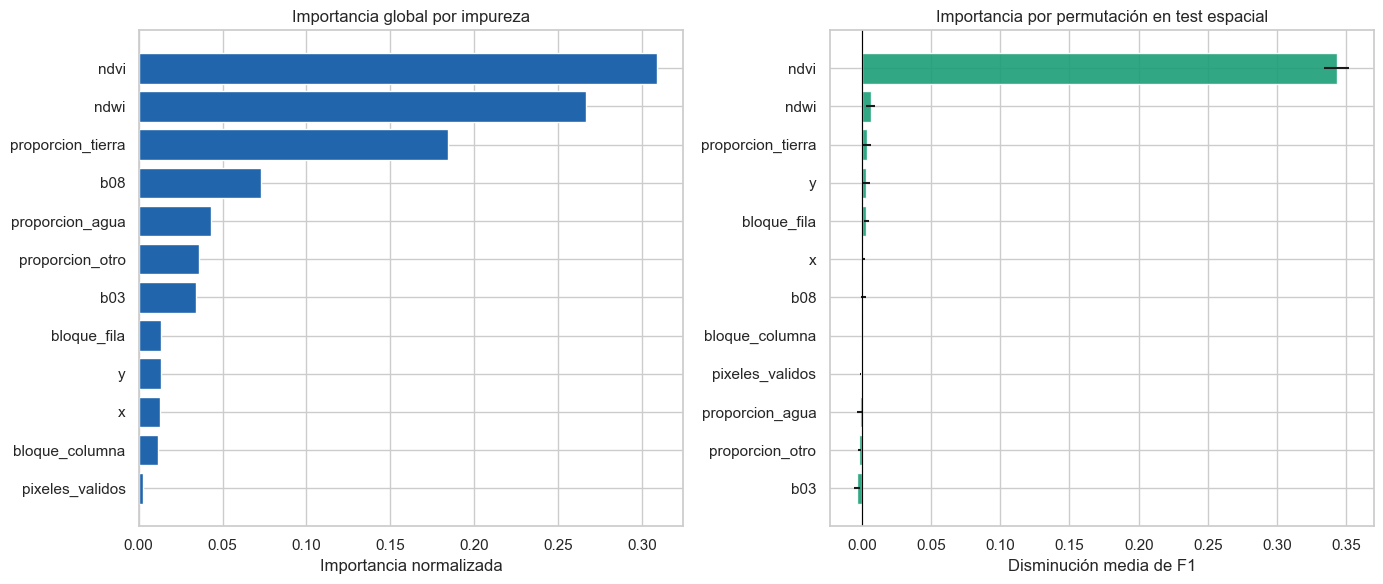

,variable,impureza,permutacion_f1,permutacion_std
0,ndvi,0.3091,0.3430,0.0091
1,ndwi,0.2668,0.0064,0.0034
2,proporcion_tierra,0.1847,0.0035,0.0029
3,b08,0.0732,0.0012,0.0017
4,proporcion_agua,0.0428,-0.0015,0.0017
5,proporcion_otro,0.0358,-0.0017,0.0014
6,b03,0.0339,-0.0035,0.0019
7,bloque_fila,0.0135,0.0033,0.0017
8,y,0.0132,0.0033,0.0023
9,x,0.0128,0.0012,0.0008


In [5]:
if not hasattr(mejor_modelo, 'feature_importances_'):
    raise TypeError('El modelo seleccionado no ofrece importancia por impureza.')

perm = permutation_importance(
    mejor_modelo, X_test, y_test, scoring='f1', n_repeats=10,
    random_state=RANDOM_STATE, n_jobs=-1
)
importancias = (pd.DataFrame({
    'variable': PREDICTORES,
    'impureza': mejor_modelo.feature_importances_,
    'permutacion_f1': perm.importances_mean,
    'permutacion_std': perm.importances_std
}).sort_values('impureza', ascending=True))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].barh(importancias['variable'], importancias['impureza'], color='#2166ac')
axes[0].set(title='Importancia global por impureza', xlabel='Importancia normalizada')
orden_perm = importancias.sort_values('permutacion_f1')
axes[1].barh(orden_perm['variable'], orden_perm['permutacion_f1'],
             xerr=orden_perm['permutacion_std'], color='#1b9e77', alpha=0.9)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set(title='Importancia por permutación en test espacial',
            xlabel='Disminución media de F1')
plt.tight_layout()
plt.show()
display(importancias.sort_values('impureza', ascending=False).reset_index(drop=True).round(4))

## 8.2. Explicación con SHAP

SHAP distribuye la diferencia entre la predicción de cada observación y la predicción base entre sus variables. En el *summary plot*, la posición horizontal es el efecto sobre la salida de la clase 1: valores SHAP positivos empujan hacia alta presencia y negativos hacia baja presencia. El color indica si el predictor toma un valor alto (rojo) o bajo (azul). Para mantener legibilidad y tiempo de ejecución se utiliza una muestra estratificada de hasta 2,000 observaciones de test.

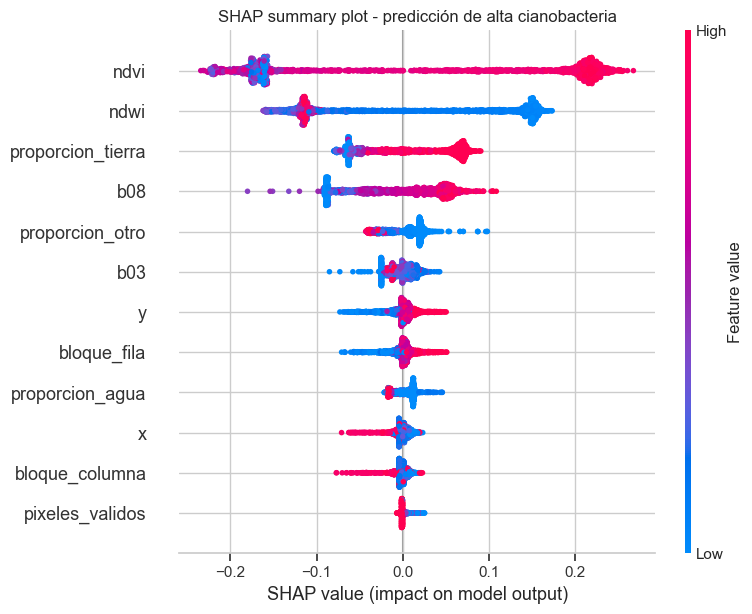

In [6]:
n_shap = min(2000, len(X_test))
muestra_idx = (pd.DataFrame({'y': y_test}, index=X_test.index)
               .groupby('y', group_keys=False)
               .apply(lambda g: g.sample(
                   n=max(1, round(n_shap * len(g) / len(X_test))),
                   random_state=RANDOM_STATE
               )).index)
muestra_idx = muestra_idx[:n_shap]
X_shap = X_test.loc[muestra_idx]

explainer = shap.TreeExplainer(mejor_modelo)
explicacion = explainer(X_shap)
# En clasificación binaria, versiones recientes de SHAP agregan una dimensión por clase.
shap_clase1 = explicacion[:, :, 1] if explicacion.values.ndim == 3 else explicacion

shap.plots.beeswarm(shap_clase1, max_display=len(PREDICTORES), show=False)
plt.title('SHAP summary plot - predicción de alta cianobacteria')
plt.tight_layout()
plt.show()

## 8.3. Dirección de los efectos

Además de inspeccionar colores, se cuantifica el patrón. `SHAP medio |x|` mide influencia global. `SHAP alto - bajo` compara el efecto medio del cuartil superior del predictor con el cuartil inferior: un valor positivo indica que valores altos tienden a elevar la predicción de clase 1; uno negativo indica que tienden a reducirla. Esta síntesis puede ocultar relaciones no lineales, por lo que después se muestran dependencias de las cuatro variables principales.

,variable,SHAP medio |x|,SHAP cuartil bajo,SHAP cuartil alto,SHAP alto - bajo,tendencia valores altos
0,ndvi,0.1728,-0.1719,0.2194,0.3913,aumentar
1,ndwi,0.1148,0.1510,-0.1165,-0.2675,disminuir
2,proporcion_tierra,0.0496,-0.0613,0.0657,0.1270,aumentar
3,b08,0.0462,-0.0753,0.0545,0.1298,aumentar
4,proporcion_otro,0.0192,0.0218,-0.0251,-0.0470,disminuir
5,b03,0.0113,-0.0048,-0.0091,-0.0043,disminuir
6,y,0.0112,-0.0208,0.0139,0.0348,aumentar
7,bloque_fila,0.0101,-0.0184,0.0140,0.0324,aumentar
8,proporcion_agua,0.0100,0.0076,-0.0078,-0.0154,disminuir
9,x,0.0068,0.0055,-0.0096,-0.0152,disminuir


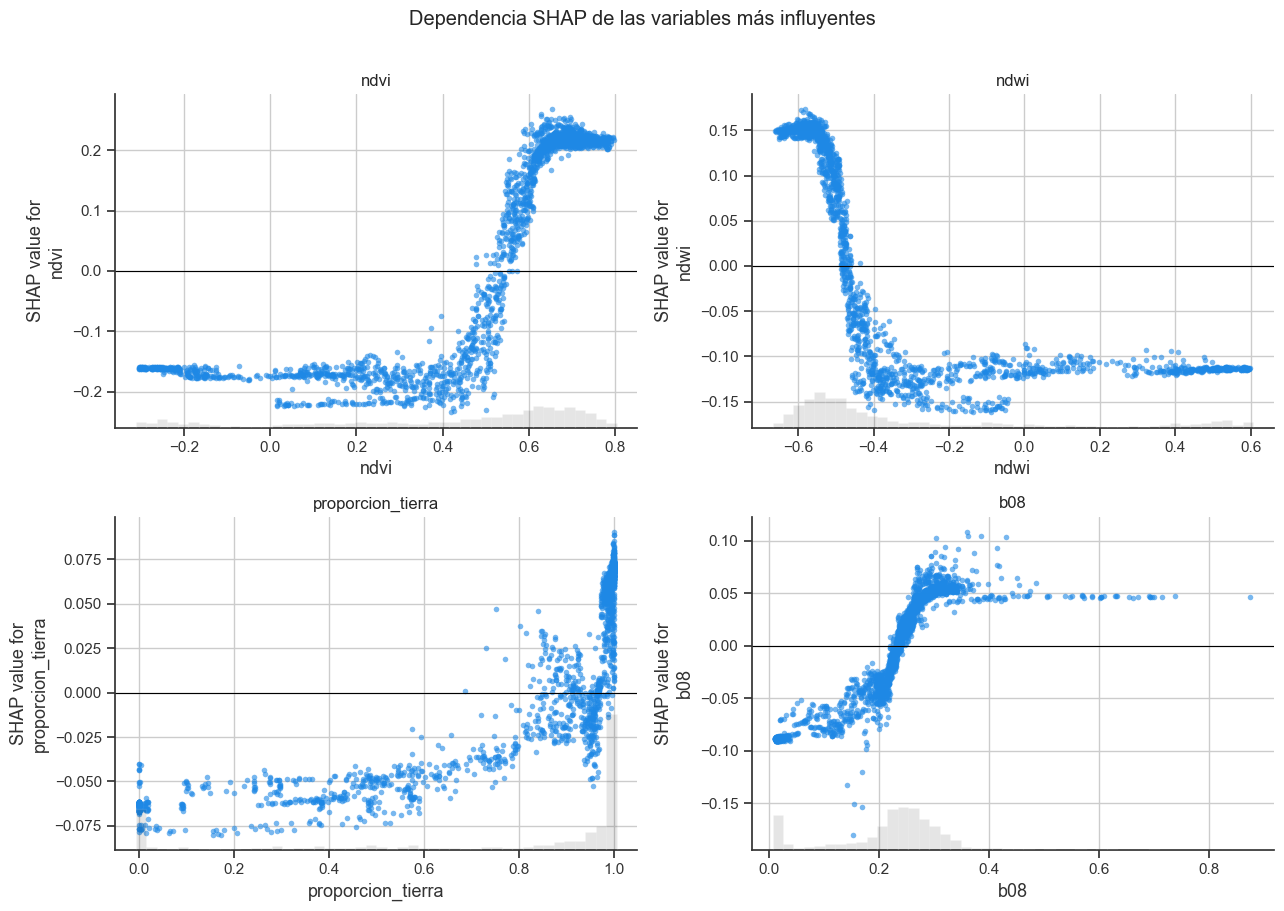

In [7]:
valores_shap = shap_clase1.values
filas_direccion = []
for j, variable in enumerate(PREDICTORES):
    q25, q75 = X_shap[variable].quantile([0.25, 0.75])
    shap_bajo = valores_shap[X_shap[variable].to_numpy() <= q25, j].mean()
    shap_alto = valores_shap[X_shap[variable].to_numpy() >= q75, j].mean()
    diferencia = shap_alto - shap_bajo
    filas_direccion.append({
        'variable': variable,
        'SHAP medio |x|': np.abs(valores_shap[:, j]).mean(),
        'SHAP cuartil bajo': shap_bajo,
        'SHAP cuartil alto': shap_alto,
        'SHAP alto - bajo': diferencia,
        'tendencia valores altos': 'aumentar' if diferencia > 0 else 'disminuir'
    })

resumen_shap = (pd.DataFrame(filas_direccion)
                .sort_values('SHAP medio |x|', ascending=False)
                .reset_index(drop=True))
display(resumen_shap.round(4))

top4 = resumen_shap.head(4)['variable'].tolist()
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for variable, ax in zip(top4, axes.flat):
    shap.plots.scatter(shap_clase1[:, variable], ax=ax, show=False, alpha=0.6)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(variable)
plt.suptitle('Dependencia SHAP de las variables más influyentes', y=1.01)
plt.tight_layout()
plt.show()

## 8.4. Interpretación ambiental

La siguiente celda genera una síntesis ligada a los resultados observados, no una explicación genérica. Las interpretaciones describen asociaciones aprendidas por el modelo y deben contrastarse con mediciones de campo.

In [8]:
contexto = {
    'b03': 'reflectancia verde, sensible a pigmentos, partículas y turbidez del agua',
    'b08': 'reflectancia del infrarrojo cercano, que puede responder a biomasa superficial, turbidez y mezcla con orillas',
    'ndvi': 'contraste NIR-rojo; en agua puede reflejar biomasa superficial, pero también vegetación ribereña y comparte B04 con la respuesta',
    'ndwi': 'contraste verde-NIR asociado al carácter acuático y a cambios ópticos de la superficie',
    'proporcion_agua': 'fracción del bloque identificada espectralmente como agua',
    'proporcion_tierra': 'fracción asociada a tierra o vegetación; puede señalar bloques de borde y depende parcialmente de NDVI',
    'proporcion_otro': 'fracción no clasificada como agua ni tierra, potencialmente relacionada con píxeles mixtos o superficies ópticamente ambiguas',
    'pixeles_validos': 'cobertura útil del bloque; puede capturar calidad de observación y geometría de las orillas',
    'x': 'posición este; representa gradientes espaciales, no un mecanismo ambiental por sí sola',
    'y': 'posición norte; representa gradientes espaciales, no un mecanismo ambiental por sí sola',
    'bloque_fila': 'ubicación norte-sur discretizada, redundante con la coordenada y',
    'bloque_columna': 'ubicación este-oeste discretizada, redundante con la coordenada x'
}

lineas = [
    f'### Síntesis obtenida\n',
    f'El modelo seleccionado fue **{nombre_mejor}**. En bloques espaciales no vistos alcanzó '
    f'**recall={comparacion.loc[nombre_mejor, "Recall"]:.3f}**, '
    f'**F1={comparacion.loc[nombre_mejor, "F1"]:.3f}** y '
    f'**ROC-AUC={comparacion.loc[nombre_mejor, "ROC-AUC"]:.3f}**.\n'
]
for _, fila in resumen_shap.head(5).iterrows():
    variable = fila['variable']
    direccion = fila['tendencia valores altos']
    lineas.append(
        f'- **{variable}** fue una de las variables más influyentes. Sus valores altos '
        f'tienden a **{direccion}** la predicción de alta presencia. Representa {contexto[variable]}. '
    )

lineas.append(
    '\nLas coordenadas y sus bloques deben entenderse como indicadores de heterogeneidad espacial: '
    'pueden resumir diferencias de profundidad, entradas de nutrientes, circulación o presión urbana, '
    'pero SHAP no permite identificar cuál mecanismo las causa. Asimismo, predictores correlacionados '
    'pueden repartirse la importancia. La interpretación es predictiva, no causal, y requiere validación '
    'con clorofila-a, recuentos de cianobacterias y variables físico-químicas medidas in situ.'
)
display(Markdown('\n'.join(lineas)))

### Síntesis obtenida

El modelo seleccionado fue **Random Forest**. En bloques espaciales no vistos alcanzó **recall=0.912**, **F1=0.909** y **ROC-AUC=0.976**.

- **ndvi** fue una de las variables más influyentes. Sus valores altos tienden a **aumentar** la predicción de alta presencia. Representa contraste NIR-rojo; en agua puede reflejar biomasa superficial, pero también vegetación ribereña y comparte B04 con la respuesta. 
- **ndwi** fue una de las variables más influyentes. Sus valores altos tienden a **disminuir** la predicción de alta presencia. Representa contraste verde-NIR asociado al carácter acuático y a cambios ópticos de la superficie. 
- **proporcion_tierra** fue una de las variables más influyentes. Sus valores altos tienden a **aumentar** la predicción de alta presencia. Representa fracción asociada a tierra o vegetación; puede señalar bloques de borde y depende parcialmente de NDVI. 
- **b08** fue una de las variables más influyentes. Sus valores altos tienden a **aumentar** la predicción de alta presencia. Representa reflectancia del infrarrojo cercano, que puede responder a biomasa superficial, turbidez y mezcla con orillas. 
- **proporcion_otro** fue una de las variables más influyentes. Sus valores altos tienden a **disminuir** la predicción de alta presencia. Representa fracción no clasificada como agua ni tierra, potencialmente relacionada con píxeles mixtos o superficies ópticamente ambiguas. 

Las coordenadas y sus bloques deben entenderse como indicadores de heterogeneidad espacial: pueden resumir diferencias de profundidad, entradas de nutrientes, circulación o presión urbana, pero SHAP no permite identificar cuál mecanismo las causa. Asimismo, predictores correlacionados pueden repartirse la importancia. La interpretación es predictiva, no causal, y requiere validación con clorofila-a, recuentos de cianobacterias y variables físico-químicas medidas in situ.

### Conclusión del inciso 8

La importancia global identifica qué variables sostienen el desempeño general, mientras SHAP muestra dirección, magnitud, dispersión y posibles no linealidades. La coincidencia entre importancia por impureza, permutación y SHAP fortalece una interpretación; sus desacuerdos pueden deberse a correlación o redundancia. Los patrones son útiles para orientar monitoreo, pero no sustituyen muestreo ambiental ni demuestran que una variable cause una floración.